# Analytic DRT Functions

This notebook implements analytic expressions for the Distribution of Relaxation Times (DRT) and impedance for the Havriliak-Negami (HN) model.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.dc import PolarisationData

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True.\ Used to achieve consistent serif fonts by rendering latex. 

%matplotlib inline

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 


## Havriliak-Negami Model

The Havriliak-Negami (HN) model provides analytic expressions for both the impedance and the DRT.

In [3]:
from redoxed.impedance.drt_analysis import HN_Z, HN_DRT, SG_DRT

In [4]:
from redoxed.impedance.drt_analysis import Z_from_DRT

## Example: Calculate and Plot HN Model

Parameters: Z0=4.0 Ω, τ0=3.0 s, α=0.99, β=0.5
Number of frequency points: 50
Number of time constant points: 50


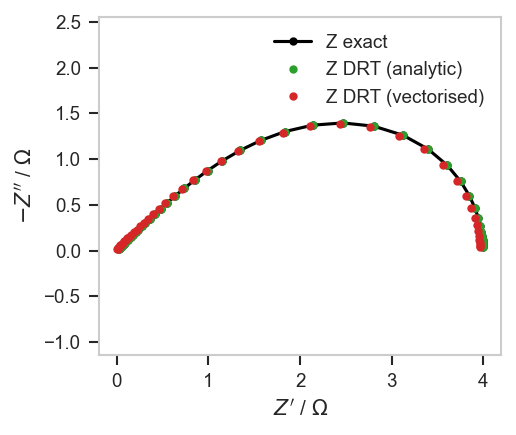

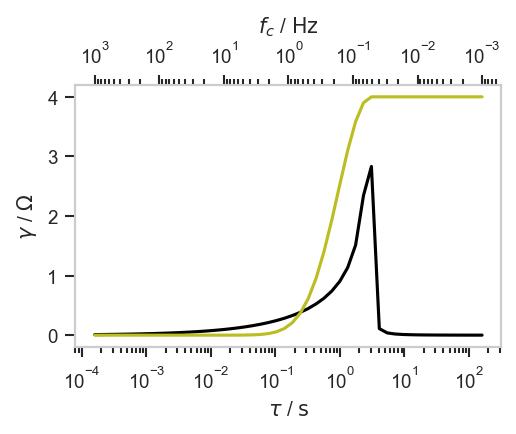

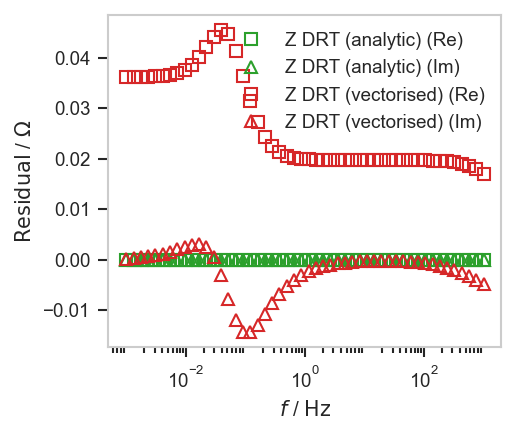

In [9]:
# Define HN parameters
Z0 = 4.      # Characteristic impedance (Ohm)
tau0 = 3.0e0      # Characteristic time constant (s)
alpha = 0.99   # Symmetric broadening parameter
beta = 0.5     # Asymmetric broadening parameter

# Create frequency array
f = np.logspace(-3, 3, 50)  # Frequency in Hz decade spacing
omega = 2 * np.pi * f        # Angular frequency in rad/s

# Create time constant array
# tau = np.logspace(-3, 3, 200)  # Time constants in s
tau = 1/omega
# tau = tau[::-1]

# Calculate impedance (analytic HN)
Z = HN_Z(omega, Z0, tau0, alpha, beta)
# Calculate DRT
gamma = HN_DRT(tau, Z0, tau0, alpha, beta)

# Reconstruct impedance from DRT (vectorized gamma)
Z_DRT_vec = Z_from_DRT(f, gamma, tau=tau, R0=0.0, L0=0.0)

# Reconstruct impedance from DRT (function/callable gamma)
def gamma_func(tau):
    return HN_DRT(tau, Z0, tau0, alpha, beta)
Z_DRT_func = Z_from_DRT(f, gamma_func, R0=0.0, L0=0.0, quad_opts={'a': -50, 'b': 50, 'epsabs': 1e-9, 'epsrel': 1e-9, 'limit': 100})

print(f"Parameters: Z0={Z0} Ω, τ0={tau0} s, α={alpha}, β={beta}")
print(f"Number of frequency points: {len(f)}")
print(f"Number of time constant points: {len(tau)}")

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

EISData_object = EISData(Z=Z, f=f)
EISData_object.label = "Z exact"
eis_plot_dict[EISData_object.label] = {
        "data": EISData(Z=Z, f=f),
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

DRTData_object = DRTData(gamma=gamma, tau=tau)
DRTData_object.label = "DRT exact"
drt_plot_dict[DRTData_object.label] = {
        "data": DRTData(gamma=gamma, tau=tau),
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
        "plot": True
    }

EISData_object = EISData(Z=Z_DRT_func, f=f)
EISData_object.label = "Z DRT (analytic)"
eis_plot_dict[EISData_object.label] = {
        "data": EISData(Z=Z_DRT_func, f=f),
        "plot_kwargs": {"color": colour_dict["green"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }
observed = EISData(Z=Z, f=f)
predicted = EISData(Z=Z_DRT_func, f=f)
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["green"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
        "plot": True
    }

EISData_object = EISData(Z=Z_DRT_vec, f=f)
EISData_object.label = "Z DRT (vectorised)"
eis_plot_dict[EISData_object.label] = {
        "data": EISData(Z=Z_DRT_vec, f=f),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }
observed = EISData(Z=Z, f=f)
predicted = EISData(Z=Z_DRT_vec, f=f)
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
        "plot": True
    }


# plot gaussian
gamma = SG_DRT(np.log10(tau), height=4.0, log_tau0=np.log10(tau0), upsilon=-0.999, sigma=1.0)
DRTData_object = DRTData(gamma=gamma, tau=tau)
DRTData_object.label = "DRT Gaussian"
drt_plot_dict[DRTData_object.label] = {
        "data": DRTData(gamma=gamma, tau=tau),
        "plot_kwargs": {"color": colour_dict["olive"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
        "plot": True
    }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(3.543, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(3.543, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
DRTPlot_object.add_major_ticks(spacing_y = 1)
# # DRTPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
# ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative') # gets a bit misleading for small Z
ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'absolute')
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)